# 02 - Prétraitement des images

Dans cette étape, nous allons préparer les images de la séquence avant l’estimation du mouvement. Le prétraitement permet de rendre les images plus adaptées à l’application du flot optique. Nous allons convertir les images en niveaux de gris, améliorer légèrement le contraste, réduire le bruit si nécessaire, et comparer les résultats avant et après prétraitement.

Le prétraitement est important car Lucas-Kanade travaille sur les variations d’intensité entre deux images successives. Des images plus propres et plus stables permettent un suivi plus fiable des points caractéristiques.

## 1. Importation des bibliothèques

Nous commençons par importer les bibliothèques nécessaires pour lire les images, les transformer et afficher les résultats.

In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Définition des chemins du dataset

Nous définissons le chemin du dataset et du dossier qui contient les images. Nous allons vérifier que les images sont bien disponibles avant de commencer le prétraitement.

In [2]:
dataset_path = Path("../data/car/car-11")
img_path = dataset_path / "img"

print("Chemin du dataset :", dataset_path)
print("Le dossier img existe :", img_path.exists())

image_extensions = [".jpg", ".png", ".jpeg"]

if img_path.exists():
    image_files = sorted([
        file for file in img_path.iterdir()
        if file.suffix.lower() in image_extensions
    ])
else:
    image_files = []
    print("Attention : le dossier img est introuvable.")

print("Nombre total d'images :", len(image_files))
print("Cinq premières images :")
for image_file in image_files[:5]:
    print("-", image_file.name)

Chemin du dataset : ..\data\car\car-11
Le dossier img existe : True
Nombre total d'images : 1661
Cinq premières images :
- 00000001.jpg
- 00000002.jpg
- 00000003.jpg
- 00000004.jpg
- 00000005.jpg


## 3. Chargement d’une image
Nous allons charger la première image de la séquence. Cette image servira d’exemple pour expliquer chaque étape du prétraitement.

Image chargée correctement.
Hauteur : 720
Largeur : 1280
Nombre de canaux : 3


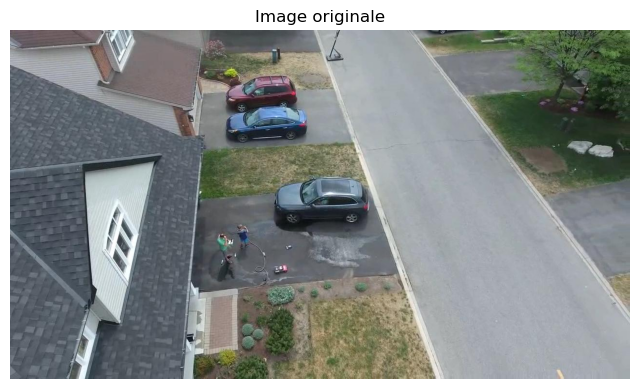

In [3]:
original_image_bgr = None
original_image_rgb = None

if len(image_files) > 0:
    original_image_bgr = cv2.imread(str(image_files[0]))

    if original_image_bgr is not None:
        height, width = original_image_bgr.shape[:2]
        channels = original_image_bgr.shape[2]
        print("Image chargée correctement.")
        print("Hauteur :", height)
        print("Largeur :", width)
        print("Nombre de canaux :", channels)

        original_image_rgb = cv2.cvtColor(original_image_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 5))
        plt.imshow(original_image_rgb)
        plt.title("Image originale")
        plt.axis("off")
        plt.show()
    else:
        print("L'image n'a pas pu être chargée.")
else:
    print("Aucune image disponible pour le chargement.")

Cette image originale nous permet d’observer l’apparence initiale de la scène avant d’appliquer les étapes de prétraitement.

## 4. Conversion en niveaux de gris

Nous convertissons l’image couleur en niveaux de gris. Cette étape simplifie l’image en gardant seulement l’information d’intensité lumineuse.

Taille de l'image grayscale : (720, 1280)


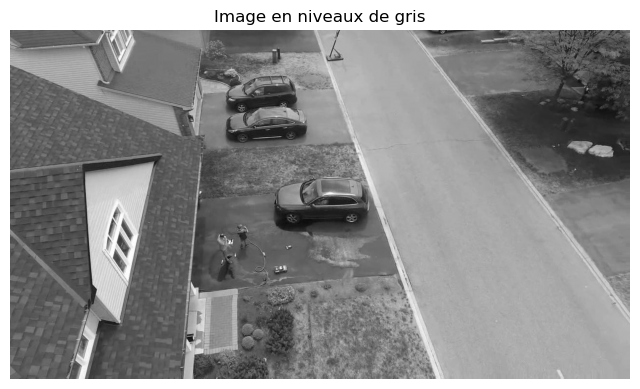

In [4]:
gray_image = None

if original_image_bgr is not None:
    gray_image = cv2.cvtColor(original_image_bgr, cv2.COLOR_BGR2GRAY)
    print("Taille de l'image grayscale :", gray_image.shape)

    plt.figure(figsize=(8, 5))
    plt.imshow(gray_image, cmap="gray")
    plt.title("Image en niveaux de gris")
    plt.axis("off")
    plt.show()
else:
    print("Impossible de convertir l'image car elle n'est pas chargée.")

La conversion en niveaux de gris permet de travailler uniquement sur l’intensité lumineuse des pixels. Cela est cohérent avec le principe du flot optique, qui se base sur les variations d’intensité entre deux images successives.

## 5. Amélioration du contraste avec CLAHE

Nous appliquons maintenant CLAHE pour améliorer localement le contraste. Nous utilisons des paramètres simples afin de garder une image naturelle.

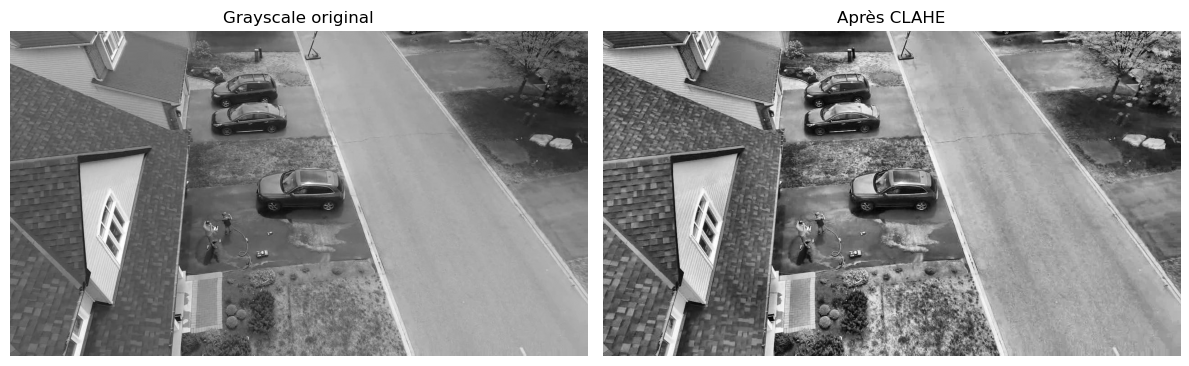

In [5]:
clahe_image = None

if gray_image is not None:
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_image = clahe.apply(gray_image)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(gray_image, cmap="gray")
    axes[0].set_title("Grayscale original")
    axes[0].axis("off")

    axes[1].imshow(clahe_image, cmap="gray")
    axes[1].set_title("Après CLAHE")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Impossible d'appliquer CLAHE car l'image grayscale n'existe pas.")

CLAHE permet d’améliorer localement le contraste de l’image. Cette étape peut aider à rendre certains détails de l’objet plus visibles, ce qui peut faciliter la détection et le suivi des points caractéristiques.

## 6. Réduction légère du bruit

Nous appliquons un filtrage gaussien léger pour réduire le bruit. Cette étape doit rester modérée pour ne pas supprimer les détails utiles.

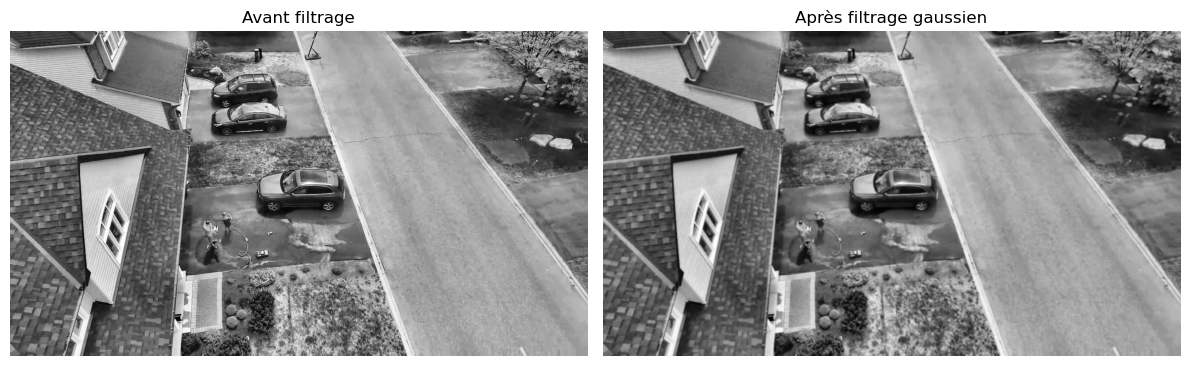

In [6]:
blurred_image = None

if clahe_image is not None:
    blurred_image = cv2.GaussianBlur(clahe_image, (5, 5), 0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(clahe_image, cmap="gray")
    axes[0].set_title("Avant filtrage")
    axes[0].axis("off")

    axes[1].imshow(blurred_image, cmap="gray")
    axes[1].set_title("Après filtrage gaussien")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Impossible d'appliquer le filtrage car l'image CLAHE n'existe pas.")

Le filtrage gaussien permet de réduire légèrement le bruit. Cependant, il ne faut pas trop lisser l’image, car les détails importants de l’objet doivent rester visibles pour le suivi.

## 7. Normalisation de l’image

Nous montrons aussi la normalisation entre 0 et 1 pour comprendre le changement d’échelle des pixels. Cette étape est présentée pour l’explication.

In [7]:
normalized_image = None

if blurred_image is not None:
    print("Avant normalisation :")
    print("- min :", blurred_image.min())
    print("- max :", blurred_image.max())

    normalized_image = blurred_image.astype(np.float32) / 255.0

    print("Après normalisation :")
    print("- min :", normalized_image.min())
    print("- max :", normalized_image.max())
else:
    print("Impossible de normaliser car l'image prétraitée n'existe pas.")

Avant normalisation :
- min : 6
- max : 254
Après normalisation :
- min : 0.023529412
- max : 0.99607843


La normalisation met les valeurs de pixels dans une échelle standard entre 0 et 1. Cela peut être utile pour certaines opérations de traitement d’image, même si OpenCV utilise souvent les images en uint8.

## 8. Comparaison complète du prétraitement

Nous comparons maintenant les principales étapes dans une même figure : image originale, niveaux de gris, CLAHE et filtrage gaussien.

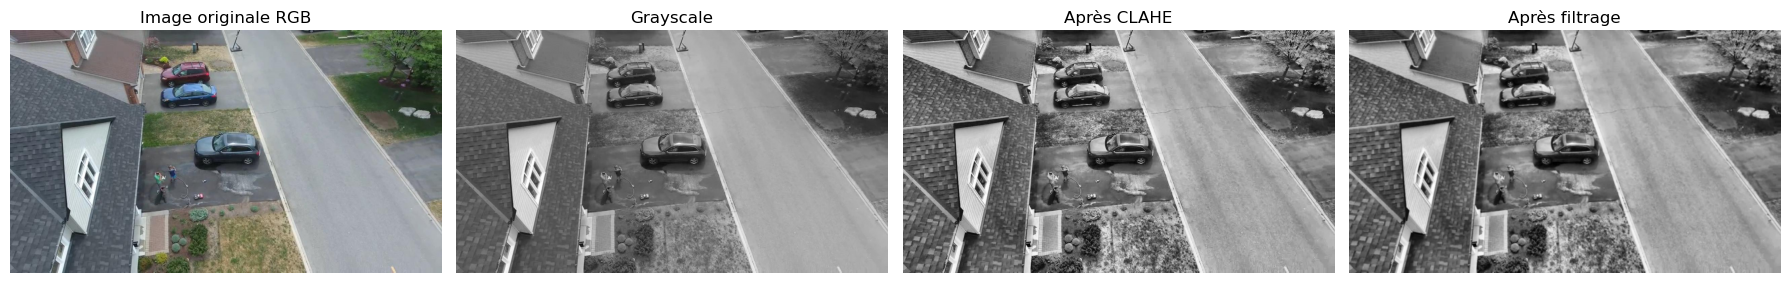

In [8]:
if original_image_rgb is not None and gray_image is not None and clahe_image is not None and blurred_image is not None:
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    axes[0].imshow(original_image_rgb)
    axes[0].set_title("Image originale RGB")
    axes[0].axis("off")

    axes[1].imshow(gray_image, cmap="gray")
    axes[1].set_title("Grayscale")
    axes[1].axis("off")

    axes[2].imshow(clahe_image, cmap="gray")
    axes[2].set_title("Après CLAHE")
    axes[2].axis("off")

    axes[3].imshow(blurred_image, cmap="gray")
    axes[3].set_title("Après filtrage")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("La comparaison complète ne peut pas être affichée car une étape manque.")

Cette comparaison nous permet de voir l’effet de chaque étape de prétraitement. L’objectif n’est pas de transformer complètement l’image, mais de la rendre plus stable et plus exploitable pour l’estimation de mouvement.

## 9. Prétraitement de plusieurs frames

Nous appliquons le même prétraitement sur cinq frames réparties dans la séquence. Cela nous permet de vérifier que le résultat reste cohérent sur plusieurs images.

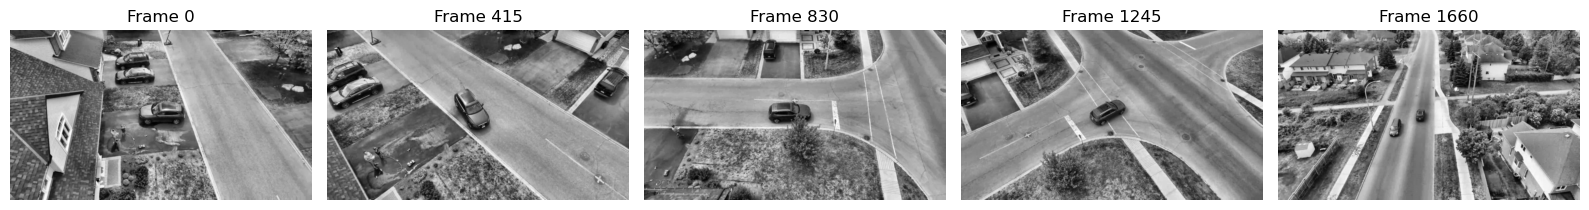

In [9]:
if len(image_files) > 0:
    frame_indices = [0, len(image_files) // 4, len(image_files) // 2, 3 * len(image_files) // 4, len(image_files) - 1]
    frame_indices = sorted(set(frame_indices))

    fig, axes = plt.subplots(1, len(frame_indices), figsize=(16, 4))
    if len(frame_indices) == 1:
        axes = [axes]

    for axis, index in zip(axes, frame_indices):
        image_bgr = cv2.imread(str(image_files[index]))

        if image_bgr is not None:
            gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            enhanced = clahe.apply(gray)
            blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)

            axis.imshow(blurred, cmap="gray")
            axis.set_title(f"Frame {index}")
        else:
            axis.set_title(f"Frame {index} non chargée")

        axis.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Impossible de prétraiter plusieurs frames car aucune image n'est disponible.")

Cette visualisation permet de vérifier que le prétraitement reste cohérent sur plusieurs images de la séquence. Cela est important car l’estimation de mouvement se fera entre images successives.

## 10. Création d’une fonction simple de prétraitement

Nous regroupons maintenant les étapes précédentes dans une fonction simple. La fonction retourne une image en `uint8`, non normalisée, afin de rester compatible avec OpenCV et avec Lucas-Kanade dans les prochaines étapes.

In [10]:
def preprocess_image(image_bgr):
    """
    Prétraite une image pour l’estimation de mouvement.
    Étapes :
    1. Conversion en niveaux de gris
    2. Amélioration du contraste avec CLAHE
    3. Filtrage gaussien léger
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    preprocessed = cv2.GaussianBlur(enhanced, (5, 5), 0)

    return preprocessed

Nous testons la fonction sur l’image exemple pour vérifier qu’elle produit bien une image prétraitée en niveaux de gris.

Type de l'image prétraitée : uint8
Taille de l'image prétraitée : (720, 1280)


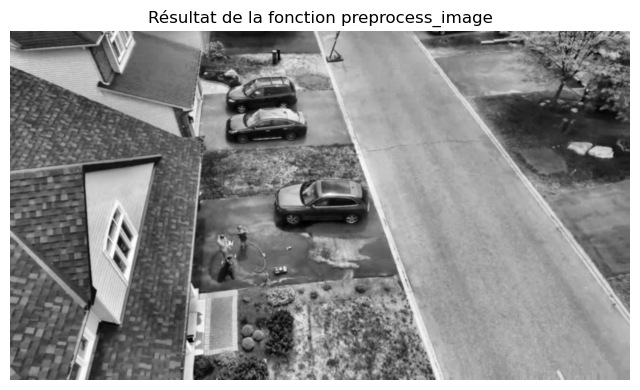

In [11]:
if original_image_bgr is not None:
    test_preprocessed = preprocess_image(original_image_bgr)
    print("Type de l'image prétraitée :", test_preprocessed.dtype)
    print("Taille de l'image prétraitée :", test_preprocessed.shape)

    plt.figure(figsize=(8, 5))
    plt.imshow(test_preprocessed, cmap="gray")
    plt.title("Résultat de la fonction preprocess_image")
    plt.axis("off")
    plt.show()
else:
    print("Impossible de tester la fonction car l'image exemple n'est pas chargée.")

## 11. Conclusion de l’étape de prétraitement

Dans cette étape, nous avons préparé les images de la séquence pour l’estimation de mouvement. Nous avons converti les images en niveaux de gris, amélioré le contraste avec CLAHE, puis appliqué un filtrage léger pour réduire le bruit. Ces images prétraitées seront utilisées dans les prochaines étapes pour détecter les points caractéristiques et appliquer la méthode de Lucas-Kanade.

Nous observons que le prétraitement reste simple et cohérent avec le cours. Il ne réalise pas encore de suivi ni d’estimation de trajectoire, mais il prépare les images pour ces étapes.